# 🛒 E-Commerce Customer Segmentation & Churn Prediction
## Machine Learning Capstone Project

**Dataset:** UCI Online Retail — 541,909 transactions (2010–2011)  
**Objective:** Segment customers by purchasing behaviour and predict churn using ML  
**Techniques:** RFM Analysis · K-Means · Hierarchical Clustering · DBSCAN · Random Forest · Gradient Boosting · Logistic Regression

---

### Project Roadmap
1. Environment Setup & Imports
2. Data Loading & Initial Inspection
3. Data Preprocessing & Cleaning
4. Exploratory Data Analysis (EDA)
5. RFM Feature Engineering
6. Data Preprocessing & Scaling
7. Customer Segmentation (K-Means · Hierarchical · DBSCAN)
8. Algorithm Comparison & Segment Analysis
9. Churn Target Definition
10. Predictive Modelling & Evaluation
11. Feature Importance & Churn Drivers
12. Inference Pipeline — Scoring New Customers
13. Business Recommendations
14. Save Trained Models & Artefacts

## 1. Environment Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import pickle
import os
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              classification_report, confusion_matrix,
                              accuracy_score, f1_score, roc_auc_score, roc_curve)
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

# ── Plotting style ──
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FFC107','#1ABC9C','#E74C3C']
sns.set_palette(PALETTE)
plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120,
                     'axes.titlesize': 13, 'axes.labelsize': 11})

os.makedirs('models', exist_ok=True)
print('✅ All libraries imported successfully')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

✅ All libraries imported successfully
Pandas: 3.0.2 | NumPy: 2.4.4


## 2. Data Loading & Initial Inspection

The dataset contains **one row per invoice line item** — a single order spans many rows. Key columns:

| Column | Description |
|---|---|
| `InvoiceNo` | Order ID (prefix `C` = cancellation) |
| `CustomerID` | Unique customer identifier (25% missing → dropped) |
| `InvoiceDate` | Transaction datetime |
| `Quantity` / `UnitPrice` | Used to derive Revenue |

In [3]:
df_raw = pd.read_excel(r'C:\Users\offic\E-COM dataset.xlsx')
print(f'Raw shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(10)

Raw shape: 541,909 rows × 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-01-12 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-01-12 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-01-12 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-01-12 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-01-12 08:34:00,1.69,13047.0,United Kingdom


In [4]:
print('=== Dataset Info ===')
df_raw.info()
print()
print('=== Missing Values ===')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
print(pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})[missing > 0])

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), object(4), str(1)
memory usage: 33.1+ MB

=== Missing Values ===
              Count  Percentage (%)
Description    1454            0.27
CustomerID   135080           24.93


In [5]:
print('=== Statistical Summary ===')
df_raw.describe()

=== Statistical Summary ===


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## 3. Data Preprocessing & Cleaning

**Decision rationale:**
- Rows without `CustomerID` are anonymous sessions — we cannot build customer profiles → **dropped**
- Cancellation invoices (prefix `C`) are return events → **excluded** to avoid negative revenue distortion
- Negative/zero `Quantity` or `UnitPrice` are data quality artifacts → **filtered out**
- `TotalPrice` (`Quantity × UnitPrice`) is derived as the revenue feature

In [6]:
df = df_raw.copy()

# 1. Parse dates
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# 2. Drop missing CustomerID
before = len(df)
df = df.dropna(subset=['CustomerID'])
print(f'Dropped {before - len(df):,} rows with missing CustomerID ({(before-len(df))/before:.1%})')

# 3. Remove cancellations
mask_cancel = df['InvoiceNo'].astype(str).str.startswith('C')
print(f'Removing {mask_cancel.sum():,} cancellation rows')
df = df[~mask_cancel]

# 4. Filter invalid transactions
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 5. Derive Revenue & fix CustomerID dtype
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['CustomerID'] = df['CustomerID'].astype(int)

# Snapshot date for RFM Recency calculation
SNAPSHOT = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f'\n✅ Clean shape: {df.shape}')
print(f'Unique customers : {df["CustomerID"].nunique():,}')
print(f'Date range       : {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')
print(f'Countries        : {df["Country"].nunique()} | Products: {df["StockCode"].nunique():,}')
print(f'Snapshot date    : {SNAPSHOT.date()}')

Dropped 135,080 rows with missing CustomerID (24.9%)
Removing 8,905 cancellation rows

✅ Clean shape: (397884, 9)
Unique customers : 4,338
Date range       : 2010-01-12 → 2011-12-10
Countries        : 37 | Products: 3,665
Snapshot date    : 2011-12-11


## 4. Exploratory Data Analysis (EDA)

We explore revenue trends over time, geographic distribution, product performance,
and customer spending patterns — all of which inform feature engineering choices.

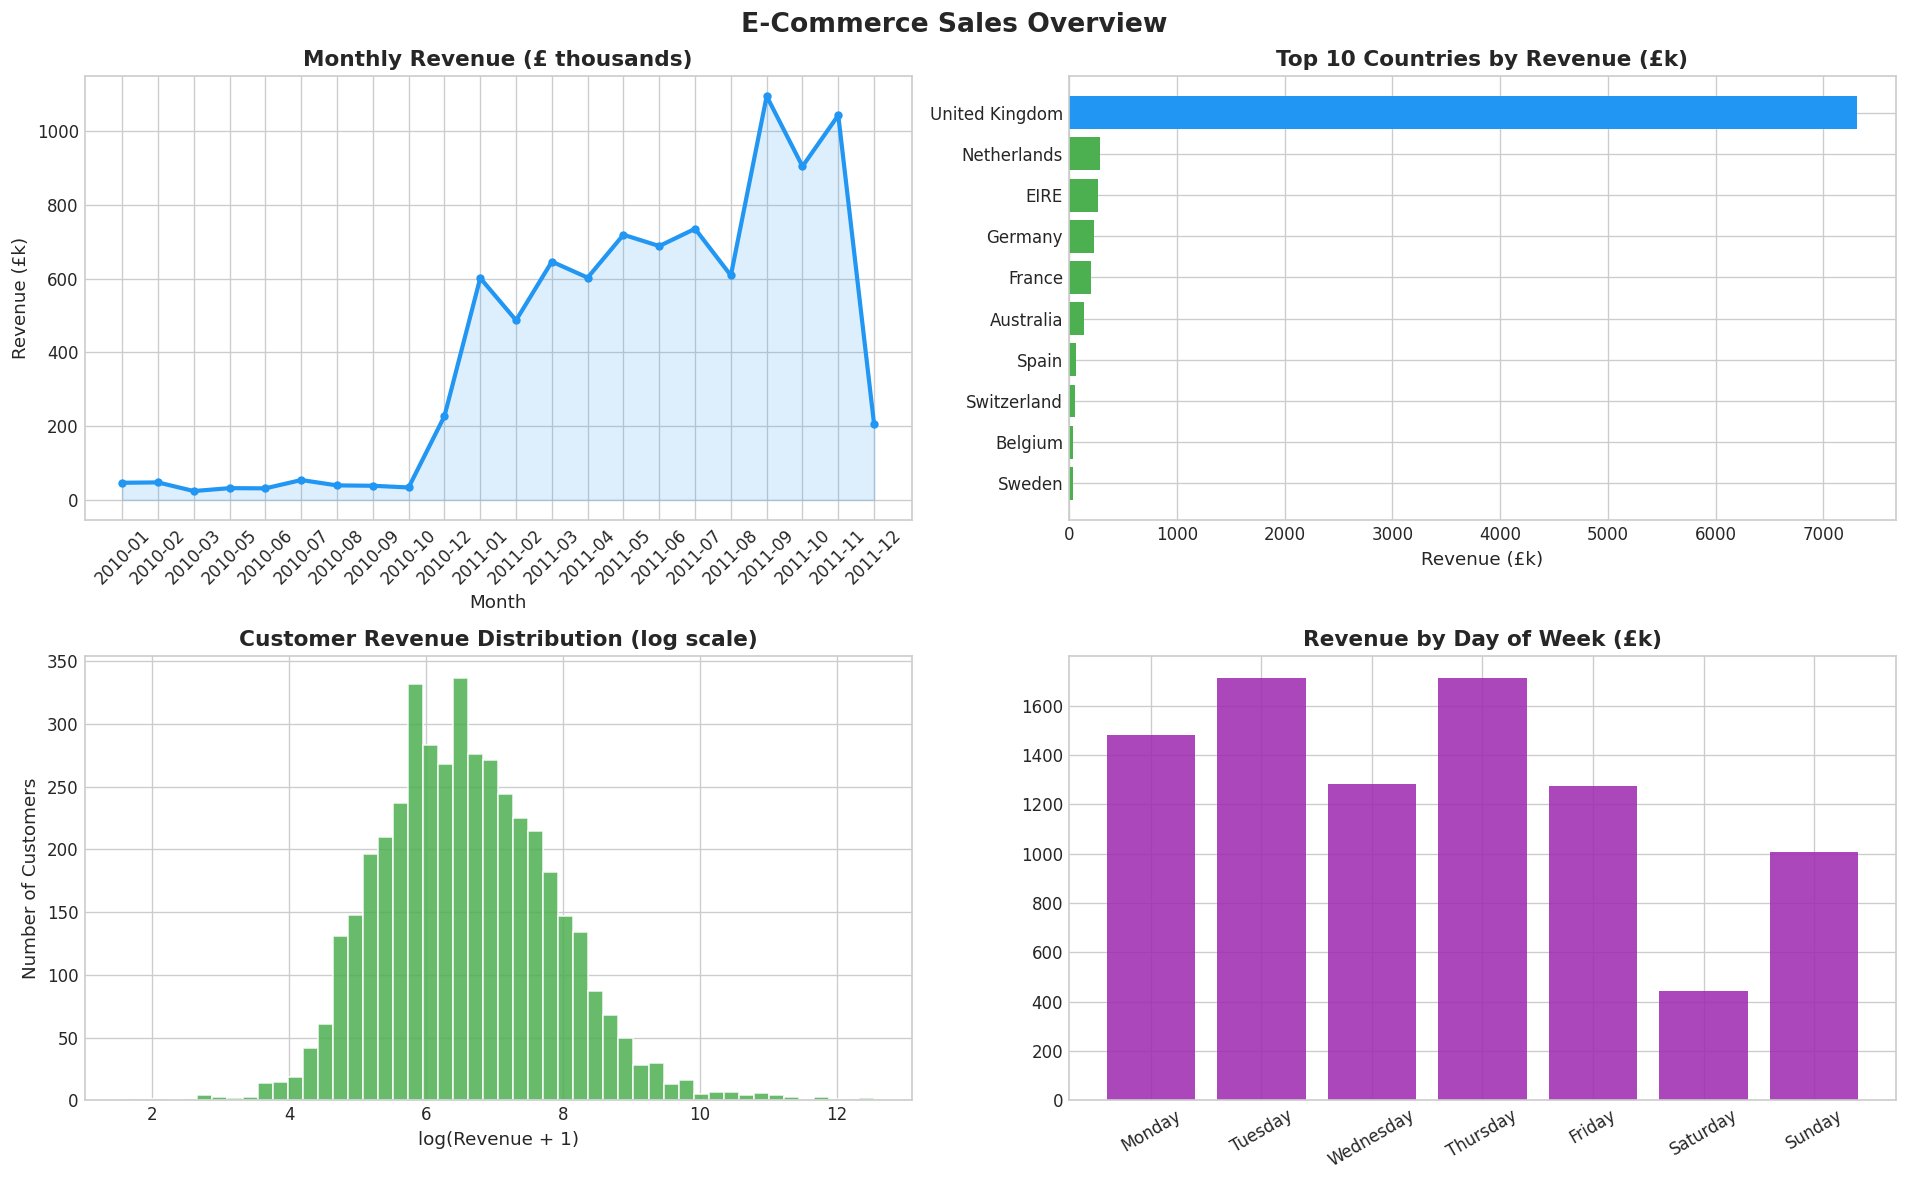

In [7]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_rev = df.groupby('YearMonth')['Revenue'].sum()
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('E-Commerce Sales Overview', fontsize=16, fontweight='bold')

# Monthly revenue
axes[0,0].plot(monthly_rev.index.astype(str), monthly_rev.values/1000,
               color=PALETTE[0], linewidth=2.5, marker='o', markersize=4)
axes[0,0].fill_between(range(len(monthly_rev)), monthly_rev.values/1000, alpha=0.15, color=PALETTE[0])
axes[0,0].set_title('Monthly Revenue (£ thousands)', fontweight='bold')
axes[0,0].set_xlabel('Month'); axes[0,0].set_ylabel('Revenue (£k)')
axes[0,0].tick_params(axis='x', rotation=45)

# Top countries
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
colors_c = [PALETTE[0] if c=='United Kingdom' else PALETTE[2] for c in top_countries.index]
axes[0,1].barh(top_countries.index[::-1], top_countries.values[::-1]/1000, color=colors_c[::-1])
axes[0,1].set_title('Top 10 Countries by Revenue (£k)', fontweight='bold')
axes[0,1].set_xlabel('Revenue (£k)')

# Customer revenue distribution
cust_rev = df.groupby('CustomerID')['Revenue'].sum()
axes[1,0].hist(np.log1p(cust_rev), bins=50, color=PALETTE[2], edgecolor='white', alpha=0.85)
axes[1,0].set_title('Customer Revenue Distribution (log scale)', fontweight='bold')
axes[1,0].set_xlabel('log(Revenue + 1)'); axes[1,0].set_ylabel('Number of Customers')

# Revenue by day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_sales = df.groupby('DayOfWeek')['Revenue'].sum().reindex(dow_order)
axes[1,1].bar(dow_sales.index, dow_sales.values/1000, color=PALETTE[3], alpha=0.85)
axes[1,1].set_title('Revenue by Day of Week (£k)', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fig1_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

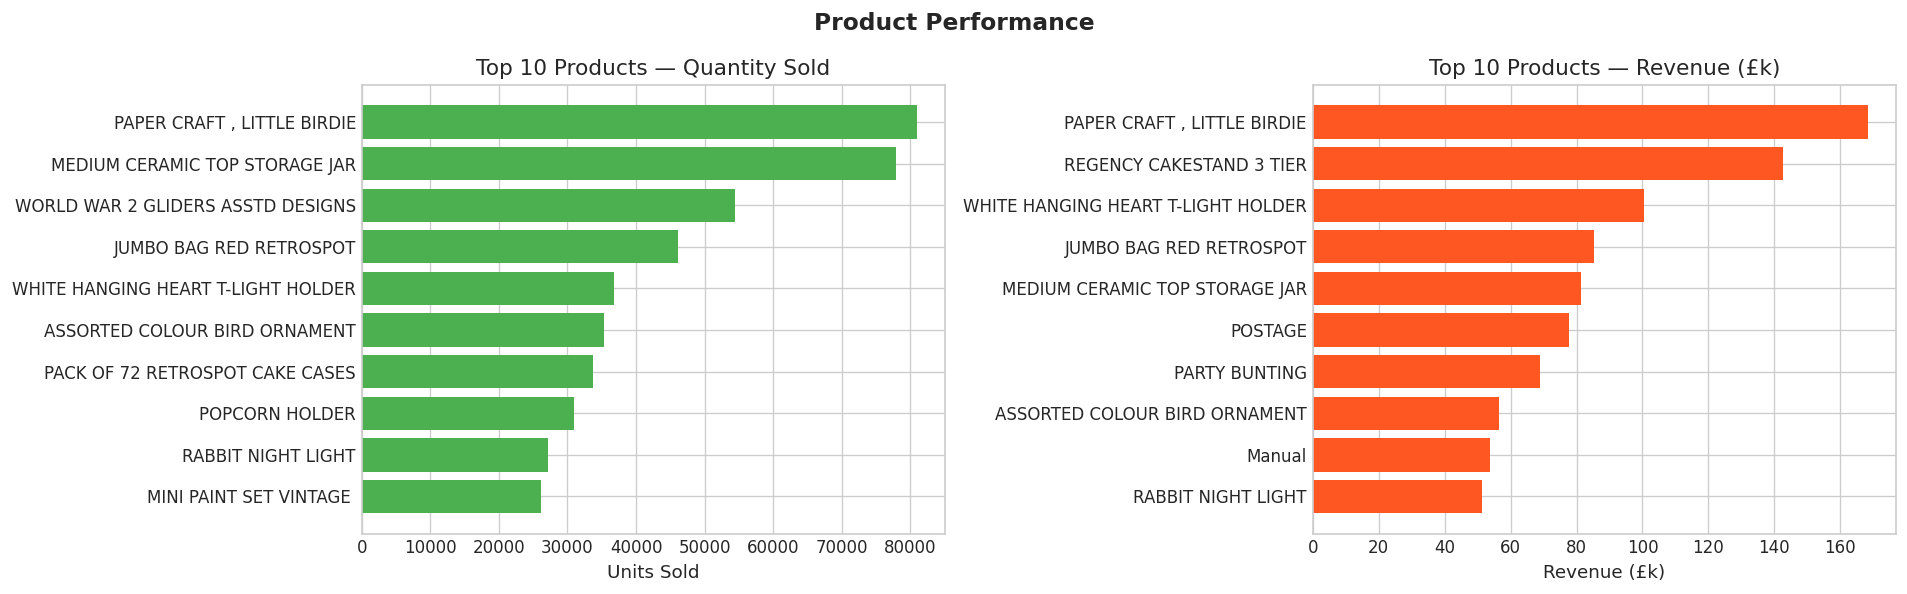

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Product Performance', fontsize=14, fontweight='bold')

top_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
axes[0].barh(top_qty.index[::-1], top_qty.values[::-1], color=PALETTE[2])
axes[0].set_title('Top 10 Products — Quantity Sold'); axes[0].set_xlabel('Units Sold')

top_rev2 = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
axes[1].barh(top_rev2.index[::-1], top_rev2.values[::-1]/1000, color=PALETTE[1])
axes[1].set_title('Top 10 Products — Revenue (£k)'); axes[1].set_xlabel('Revenue (£k)')

plt.tight_layout()
plt.savefig('fig2_product_insights.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. RFM Feature Engineering

### RFM Framework
RFM is a classical marketing model that segments customers on three axes:

| Feature | Meaning | Why it matters |
|---|---|---|
| **Recency (R)** | Days since last purchase | Recent buyers are more likely to buy again |
| **Frequency (F)** | Number of unique invoices | High frequency = habitual, loyal customer |
| **Monetary (M)** | Total spend (£) | Captures customer lifetime value |

### Additional Behavioural Features
Beyond RFM, we engineer features capturing *how* customers shop:
product diversity, average order value, tenure, and weekend/weekday patterns.
These enrich the cluster space and improve churn prediction power.

In [9]:
rfm = df.groupby('CustomerID').agg(
    Recency        = ('InvoiceDate', lambda x: (SNAPSHOT - x.max()).days),
    Frequency      = ('InvoiceNo',   'nunique'),
    Monetary       = ('Revenue',     'sum'),
    TotalQty       = ('Quantity',    'sum'),
    NumProducts    = ('StockCode',   'nunique'),
    Tenuredays     = ('InvoiceDate', lambda x: (x.max()-x.min()).days),
    AvgTimeBetween = ('InvoiceDate', lambda x:
                       (x.max()-x.min()).days/(x.nunique()-1) if x.nunique()>1 else 0),
    PurchasedWeekend=('InvoiceDate', lambda x: int(x.dt.dayofweek.isin([5,6]).any())),
).reset_index()

rfm['AvgOrderValue']  = rfm['Monetary'] / rfm['Frequency']
rfm['RevenuePerVisit'] = rfm['Monetary'] / rfm['Frequency']

# Log-transform right-skewed features
for col in ['Recency','Frequency','Monetary','AvgOrderValue','NumProducts']:
    rfm[f'log_{col}'] = np.log1p(rfm[col])

# RFM Quintile Scores (1=worst, 5=best)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print(f'RFM table shape: {rfm.shape}')
print()
rfm[['Recency','Frequency','Monetary','AvgOrderValue']].describe().round(2)

RFM table shape: (4338, 20)



,Recency,Frequency,Monetary,AvgOrderValue
count,4338.00,4338.00,4338.00,4338.00
mean,106.47,4.27,2054.27,419.17
std,115.08,7.70,8989.23,1796.54
min,1.00,1.00,3.75,3.45
25%,23.00,1.00,307.41,178.62
50%,62.00,2.00,674.48,293.90
75%,162.75,5.00,1661.74,430.11
max,698.00,209.00,280206.02,84236.25


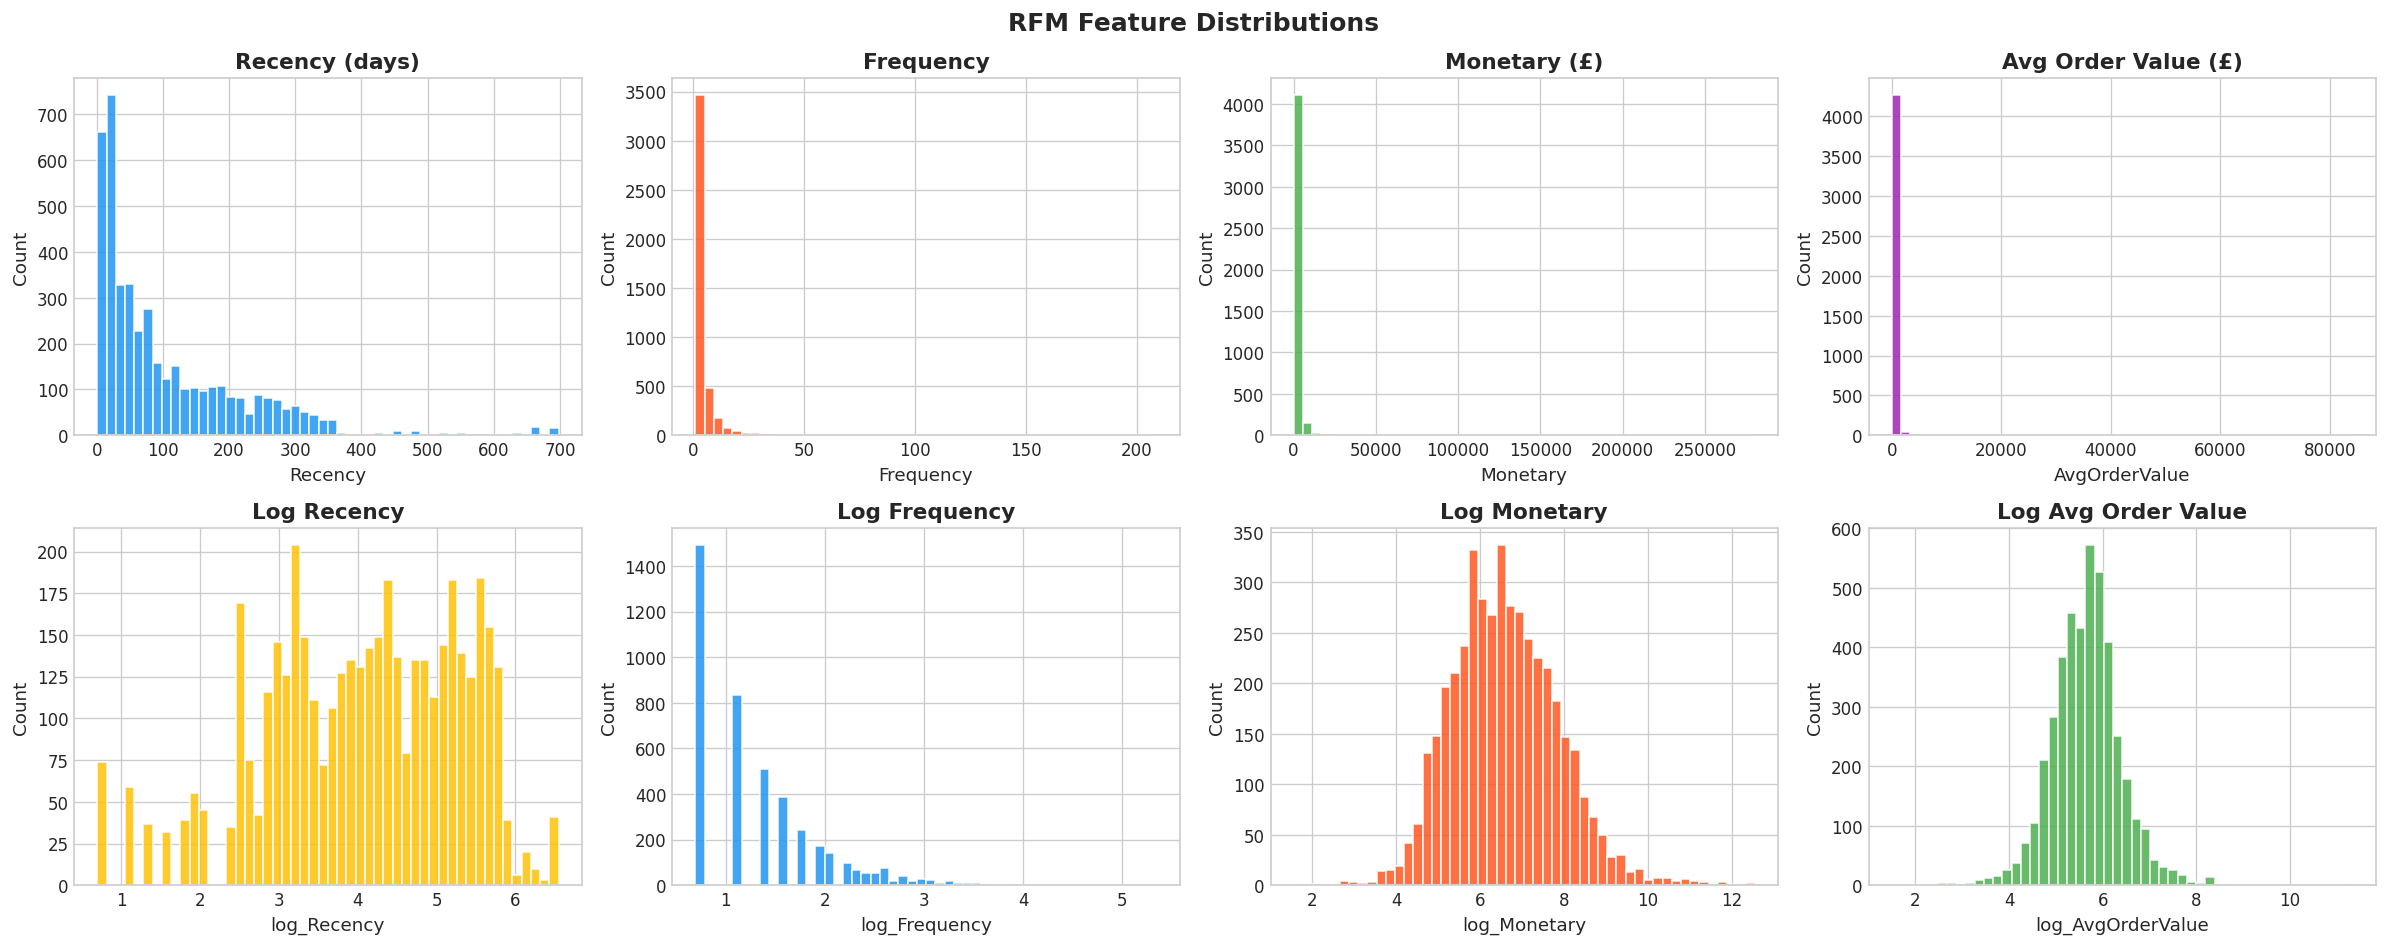

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
cols_titles = [
    ('Recency','Recency (days)'),('Frequency','Frequency'),
    ('Monetary','Monetary (£)'),('AvgOrderValue','Avg Order Value (£)'),
    ('log_Recency','Log Recency'),('log_Frequency','Log Frequency'),
    ('log_Monetary','Log Monetary'),('log_AvgOrderValue','Log Avg Order Value')
]
for idx, (col, title) in enumerate(cols_titles):
    ax = axes[idx//4][idx%4]
    ax.hist(rfm[col], bins=50, color=PALETTE[idx%5], edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel(col); ax.set_ylabel('Count')
plt.suptitle('RFM Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

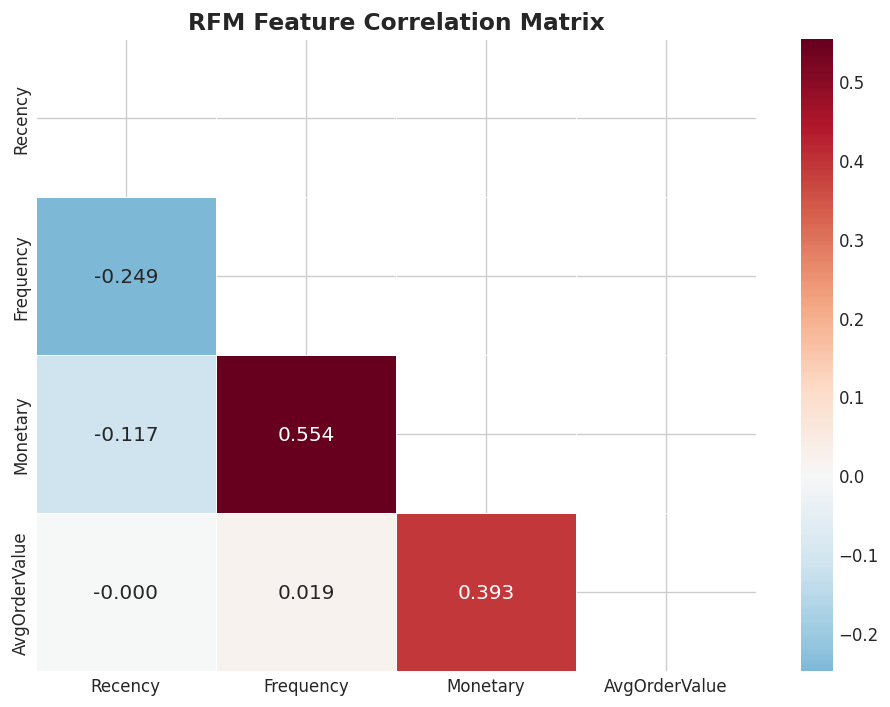

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
corr_cols = ['Recency','Frequency','Monetary','AvgOrderValue']
corr = rfm[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            ax=ax, mask=mask, linewidths=0.5, annot_kws={'size': 12})
ax.set_title('RFM Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_rfm_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Data Preprocessing & Scaling

We apply **log-transformation** (to reduce skew) followed by **StandardScaler**
(to give equal weight to all features). Without scaling, `Monetary` (£0–£280K)
would dominate distance calculations over `Frequency` (1–209).

Clustering features include both RFM log-transforms and behavioural features.

In [12]:
CLUSTER_FEATURES = ['log_Recency','log_Frequency','log_Monetary',
                    'log_AvgOrderValue','NumProducts','Tenuredays','PurchasedWeekend']

X_clust = rfm[CLUSTER_FEATURES].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

print(f'Feature matrix : {X_scaled.shape}')
print(f'Features used  : {CLUSTER_FEATURES}')
print(f'Post-scaling mean ≈ {X_scaled.mean(axis=0).round(3)}')
print(f'Post-scaling std  ≈ {X_scaled.std(axis=0).round(3)}')

Feature matrix : (4338, 7)
Features used  : ['log_Recency', 'log_Frequency', 'log_Monetary', 'log_AvgOrderValue', 'NumProducts', 'Tenuredays', 'PurchasedWeekend']
Post-scaling mean ≈ [ 0. -0.  0.  0. -0.  0. -0.]
Post-scaling std  ≈ [1. 1. 1. 1. 1. 1. 1.]


## 7. Customer Segmentation

### 7.1 K-Means — Optimal k Selection

We use three complementary criteria to select the optimal number of clusters:
- **Elbow method:** Inertia drops steeply until k=4, then flattens
- **Silhouette score:** Measures cluster cohesion vs. separation (higher = better)
- **Davies-Bouldin score:** Ratio of within-cluster scatter to between-cluster separation (lower = better)

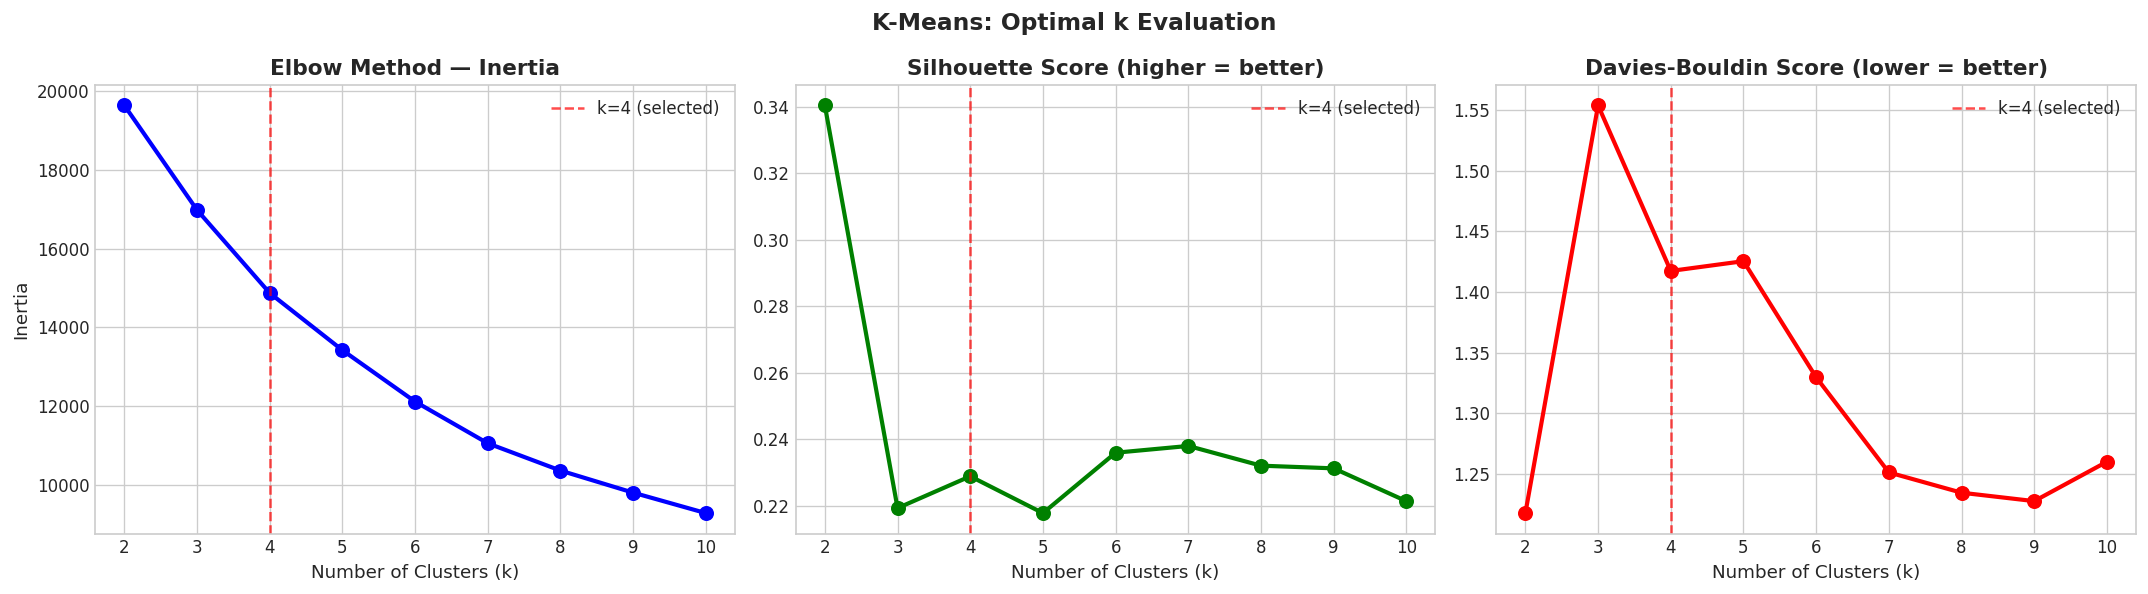

Selected k=4
  Silhouette Score : 0.2289
  Davies-Bouldin   : 1.4173


In [13]:
K_RANGE = range(2, 11)
inertias, sil_scores, db_scores = [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=2000))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(K_RANGE, inertias, 'bo-', linewidth=2.5, markersize=8)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (selected)')
axes[0].set_title('Elbow Method — Inertia', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)'); axes[0].set_ylabel('Inertia'); axes[0].legend()

axes[1].plot(K_RANGE, sil_scores, 'go-', linewidth=2.5, markersize=8)
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (selected)')
axes[1].set_title('Silhouette Score (higher = better)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)'); axes[1].legend()

axes[2].plot(K_RANGE, db_scores, 'ro-', linewidth=2.5, markersize=8)
axes[2].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (selected)')
axes[2].set_title('Davies-Bouldin Score (lower = better)', fontweight='bold')
axes[2].set_xlabel('Number of Clusters (k)'); axes[2].legend()

plt.suptitle('K-Means: Optimal k Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_kmeans_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = 4
print(f'Selected k={best_k}')
print(f'  Silhouette Score : {sil_scores[best_k-2]:.4f}')
print(f'  Davies-Bouldin   : {db_scores[best_k-2]:.4f}')

In [14]:
# Final K-Means model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
rfm['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

# Re-order clusters by descending monetary value
order = rfm.groupby('Cluster_KMeans')['Monetary'].mean().sort_values(ascending=False).index
cluster_map = {old: new for new, old in enumerate(order)}
rfm['Cluster_KMeans'] = rfm['Cluster_KMeans'].map(cluster_map)

SEGMENT_LABELS = {0:'Champions', 1:'Loyal Customers', 2:'Occasional Buyers', 3:'At-Risk / Dormant'}
SEG_COLORS = {'Champions':'#FF5722','Loyal Customers':'#2196F3',
              'Occasional Buyers':'#4CAF50','At-Risk / Dormant':'#9C27B0'}
rfm['Segment'] = rfm['Cluster_KMeans'].map(SEGMENT_LABELS)

km_sil = silhouette_score(X_scaled, rfm['Cluster_KMeans'])
km_db  = davies_bouldin_score(X_scaled, rfm['Cluster_KMeans'])
print(f'K-Means (k=4) — Silhouette={km_sil:.4f} | Davies-Bouldin={km_db:.4f}')
print()
print('Cluster Centroids (original scale):')
rfm.groupby('Segment')[['Recency','Frequency','Monetary','AvgOrderValue']].mean().round(2)

K-Means (k=4) — Silhouette=0.2320 | Davies-Bouldin=1.4159

Cluster Centroids (original scale):


,Recency,Frequency,Monetary,AvgOrderValue
Segment,,,,
At-Risk / Dormant,191.18,1.29,233.06,196.24
Champions,24.25,13.22,7524.18,503.75
Loyal Customers,80.89,2.76,1483.61,679.01
Occasional Buyers,86.47,3.32,1047.30,341.25


### 7.2 Hierarchical Clustering (Ward Linkage)

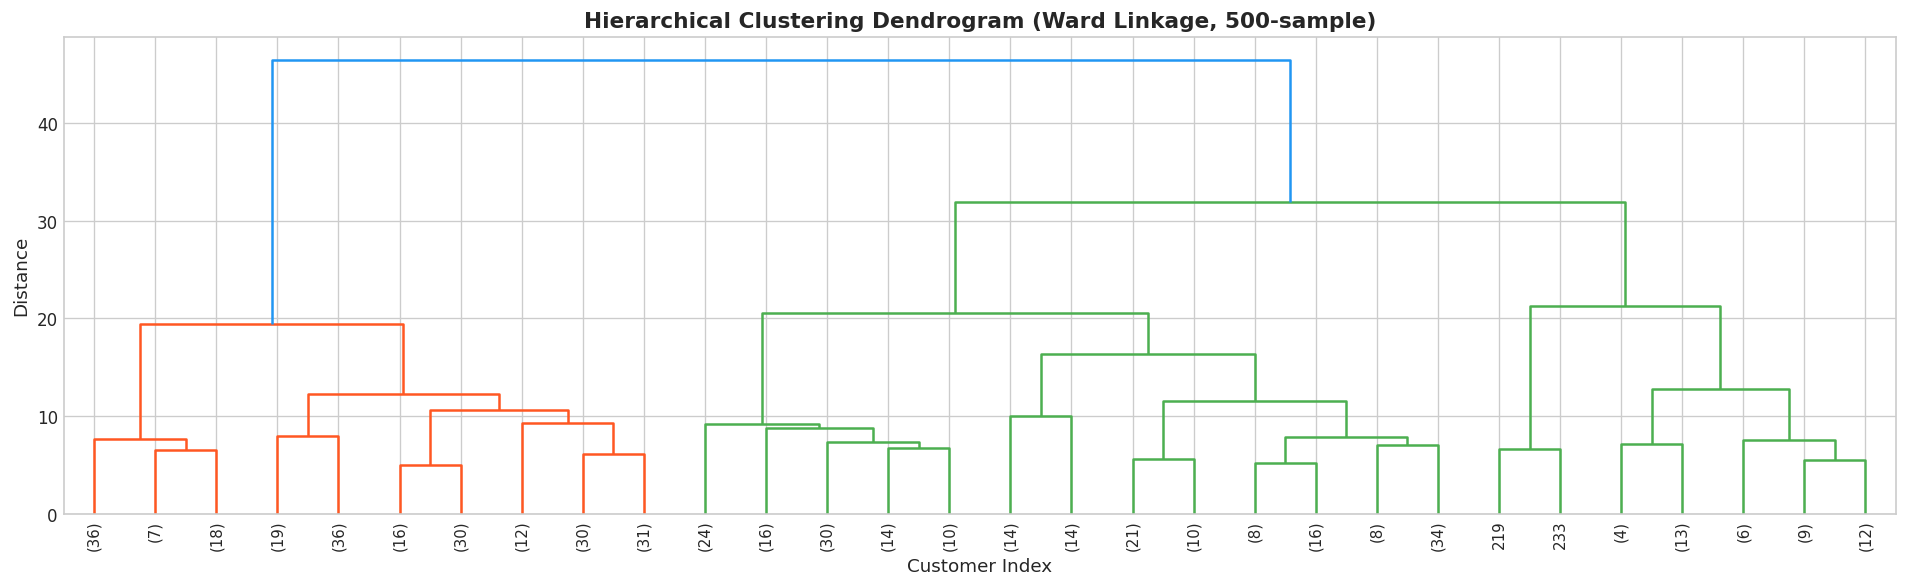

Hierarchical (k=4) — Silhouette=0.2168 | Davies-Bouldin=1.3927


In [15]:
# Dendrogram on 500-sample for visualisation
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), 500, replace=False)
Z = linkage(X_scaled[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(16, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9,
           color_threshold=0.7*max(Z[:,2]))
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage, 500-sample)', fontweight='bold')
ax.set_xlabel('Customer Index'); ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig('fig6_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Apply to full data
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
rfm['Cluster_HC'] = hc.fit_predict(X_scaled)
hc_sil = silhouette_score(X_scaled, rfm['Cluster_HC'])
hc_db  = davies_bouldin_score(X_scaled, rfm['Cluster_HC'])
print(f'Hierarchical (k=4) — Silhouette={hc_sil:.4f} | Davies-Bouldin={hc_db:.4f}')

### 7.3 DBSCAN — Density-Based Clustering

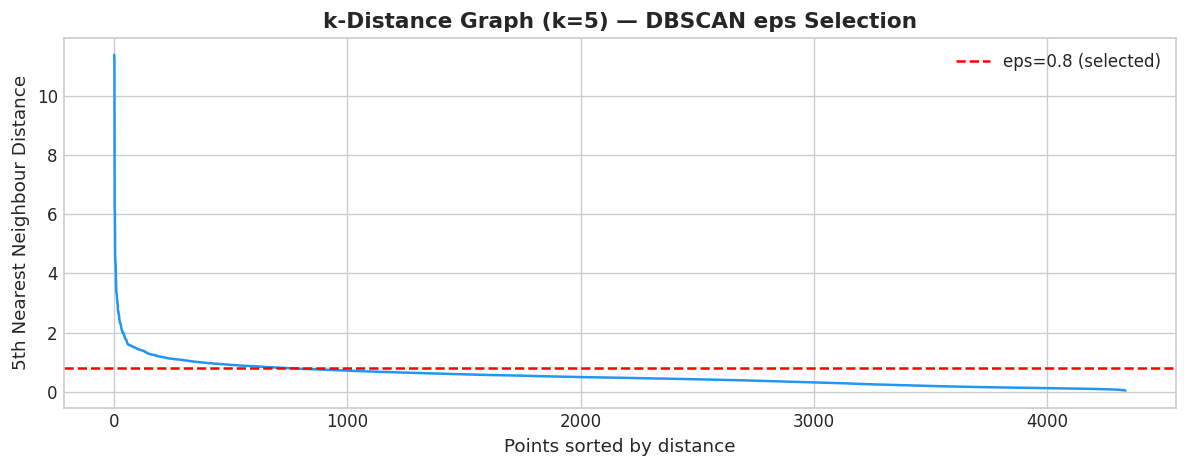

DBSCAN: 2 clusters, 717 noise points (16.5%)
DBSCAN Silhouette (non-noise): 0.2991


In [16]:
# k-distance plot to find eps
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, 4])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_dist, color=PALETTE[0])
ax.axhline(y=0.8, color='red', linestyle='--', label='eps=0.8 (selected)')
ax.set_title('k-Distance Graph (k=5) — DBSCAN eps Selection', fontweight='bold')
ax.set_xlabel('Points sorted by distance'); ax.set_ylabel('5th Nearest Neighbour Distance')
ax.legend(); plt.tight_layout()
plt.savefig('fig7_dbscan_eps.png', dpi=150, bbox_inches='tight')
plt.show()

dbscan = DBSCAN(eps=0.8, min_samples=10)
rfm['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)
n_db = len(set(rfm['Cluster_DBSCAN'])) - (1 if -1 in rfm['Cluster_DBSCAN'].values else 0)
n_noise = (rfm['Cluster_DBSCAN'] == -1).sum()
non_noise = rfm['Cluster_DBSCAN'] != -1
print(f'DBSCAN: {n_db} clusters, {n_noise} noise points ({n_noise/len(rfm)*100:.1f}%)')
if n_db > 1:
    db_sil = silhouette_score(X_scaled[non_noise], rfm.loc[non_noise,'Cluster_DBSCAN'])
    print(f'DBSCAN Silhouette (non-noise): {db_sil:.4f}')

In [17]:
# =========================
# DBSCAN INSIGHTS
# =========================

noise_points = rfm[rfm['Cluster_DBSCAN'] == -1]

print(f"Noise points (potential outliers): {len(noise_points)}")

print("\nAverage metrics for noise points:")
print(noise_points[['Monetary', 'Frequency', 'Recency']].mean())

Noise points (potential outliers): 717

Average metrics for noise points:
Monetary     7614.234353
Frequency      11.132497
Recency        50.517434
dtype: float64


DBSCAN identifies outliers which may represent:
- High-value bulk buyers
- Irregular purchasing patterns
- Potential fraud or anomalous transactions

These customers require special handling strategies.

## 8. Algorithm Comparison & Segment Analysis

In [18]:
comparison = pd.DataFrame({
    'Algorithm'      : ['K-Means (k=4)', 'Hierarchical (k=4)', 'DBSCAN'],
    'N Clusters'     : [4, 4, n_db],
    'Silhouette Score': [round(km_sil,4), round(hc_sil,4), round(db_sil,4) if n_db>1 else None],
    'Davies-Bouldin' : [round(km_db,4), round(hc_db,4), None]
})
print(comparison.to_string(index=False))
print()
print('✅ K-Means selected as primary model (highest silhouette, most interpretable segments)')

         Algorithm  N Clusters  Silhouette Score  Davies-Bouldin
     K-Means (k=4)           4            0.2320          1.4159
Hierarchical (k=4)           4            0.2168          1.3927
            DBSCAN           2            0.2991             NaN

✅ K-Means selected as primary model (highest silhouette, most interpretable segments)


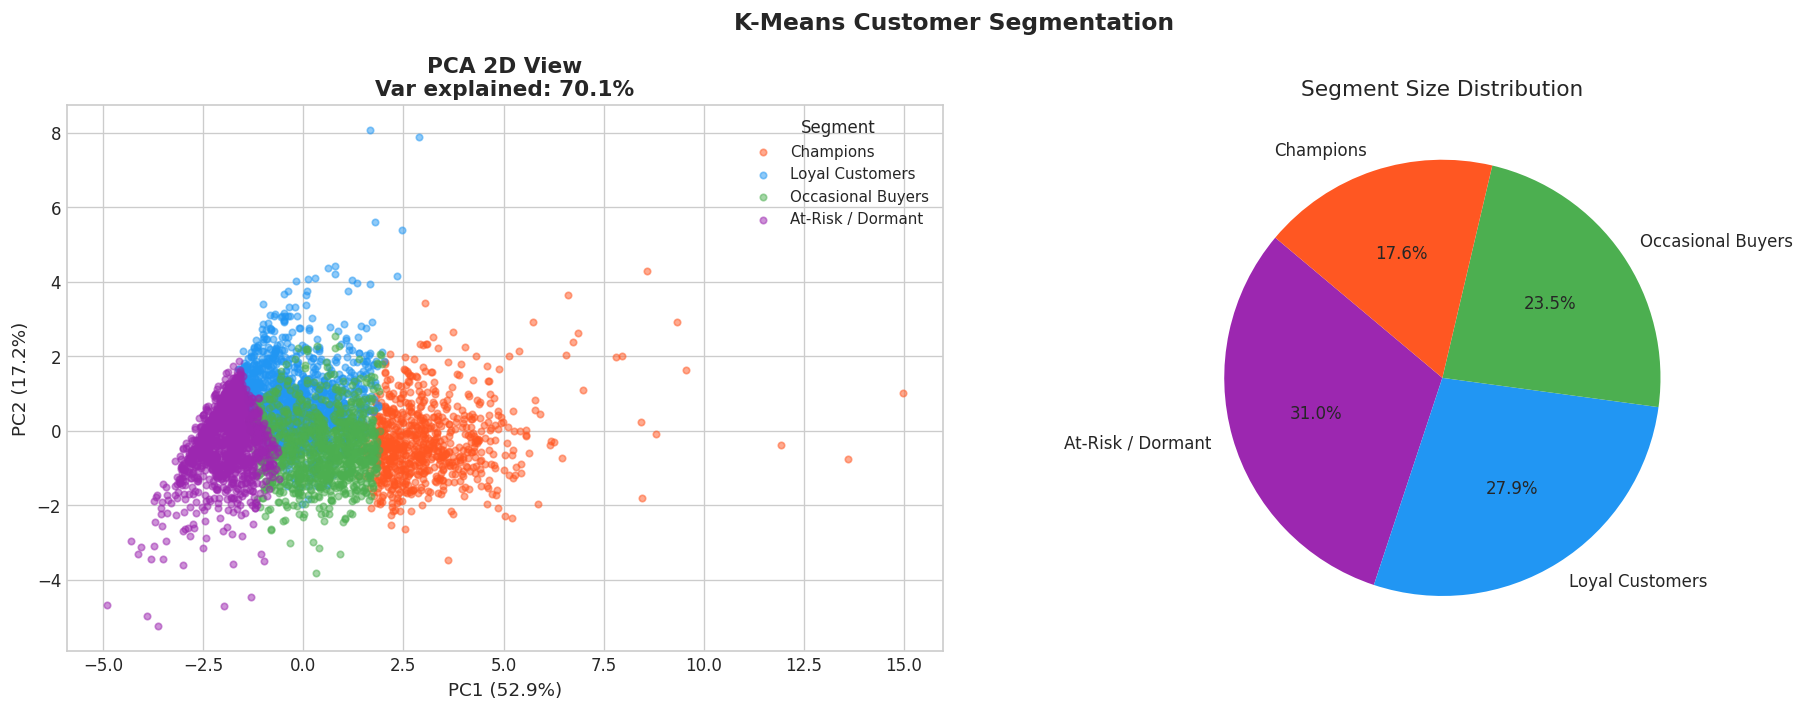

In [19]:
# PCA 2D visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-Means Customer Segmentation', fontsize=14, fontweight='bold')

for seg, color in SEG_COLORS.items():
    mask_s = rfm['Segment'] == seg
    axes[0].scatter(X_pca[mask_s,0], X_pca[mask_s,1], c=color, label=seg, alpha=0.5, s=15)
axes[0].set_title(f'PCA 2D View\nVar explained: {sum(pca.explained_variance_ratio_)*100:.1f}%', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(title='Segment', fontsize=9)

seg_counts = rfm['Segment'].value_counts()
axes[1].pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
            colors=[SEG_COLORS[s] for s in seg_counts.index], startangle=140)
axes[1].set_title('Segment Size Distribution')
plt.tight_layout()
plt.savefig('fig8_kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
total_rev = rfm['Monetary'].sum()
seg_stats = rfm.groupby('Segment').agg(
    Count        = ('CustomerID','count'),
    Avg_Recency  = ('Recency','mean'),
    Avg_Freq     = ('Frequency','mean'),
    Avg_Monetary = ('Monetary','mean'),
    Total_Revenue= ('Monetary','sum')
).round(2)
seg_stats['Revenue_Share_%'] = (seg_stats['Total_Revenue']/total_rev*100).round(2)
print(seg_stats.to_string())

                   Count  Avg_Recency  Avg_Freq  Avg_Monetary  Total_Revenue  Revenue_Share_%
Segment                                                                                      
At-Risk / Dormant   1346       191.18      1.29        233.06      313702.12             3.52
Champions            762        24.25     13.22       7524.18     5733421.48            64.34
Loyal Customers     1212        80.89      2.76       1483.61     1798132.07            20.18
Occasional Buyers   1018        86.47      3.32       1047.30     1066152.23            11.96


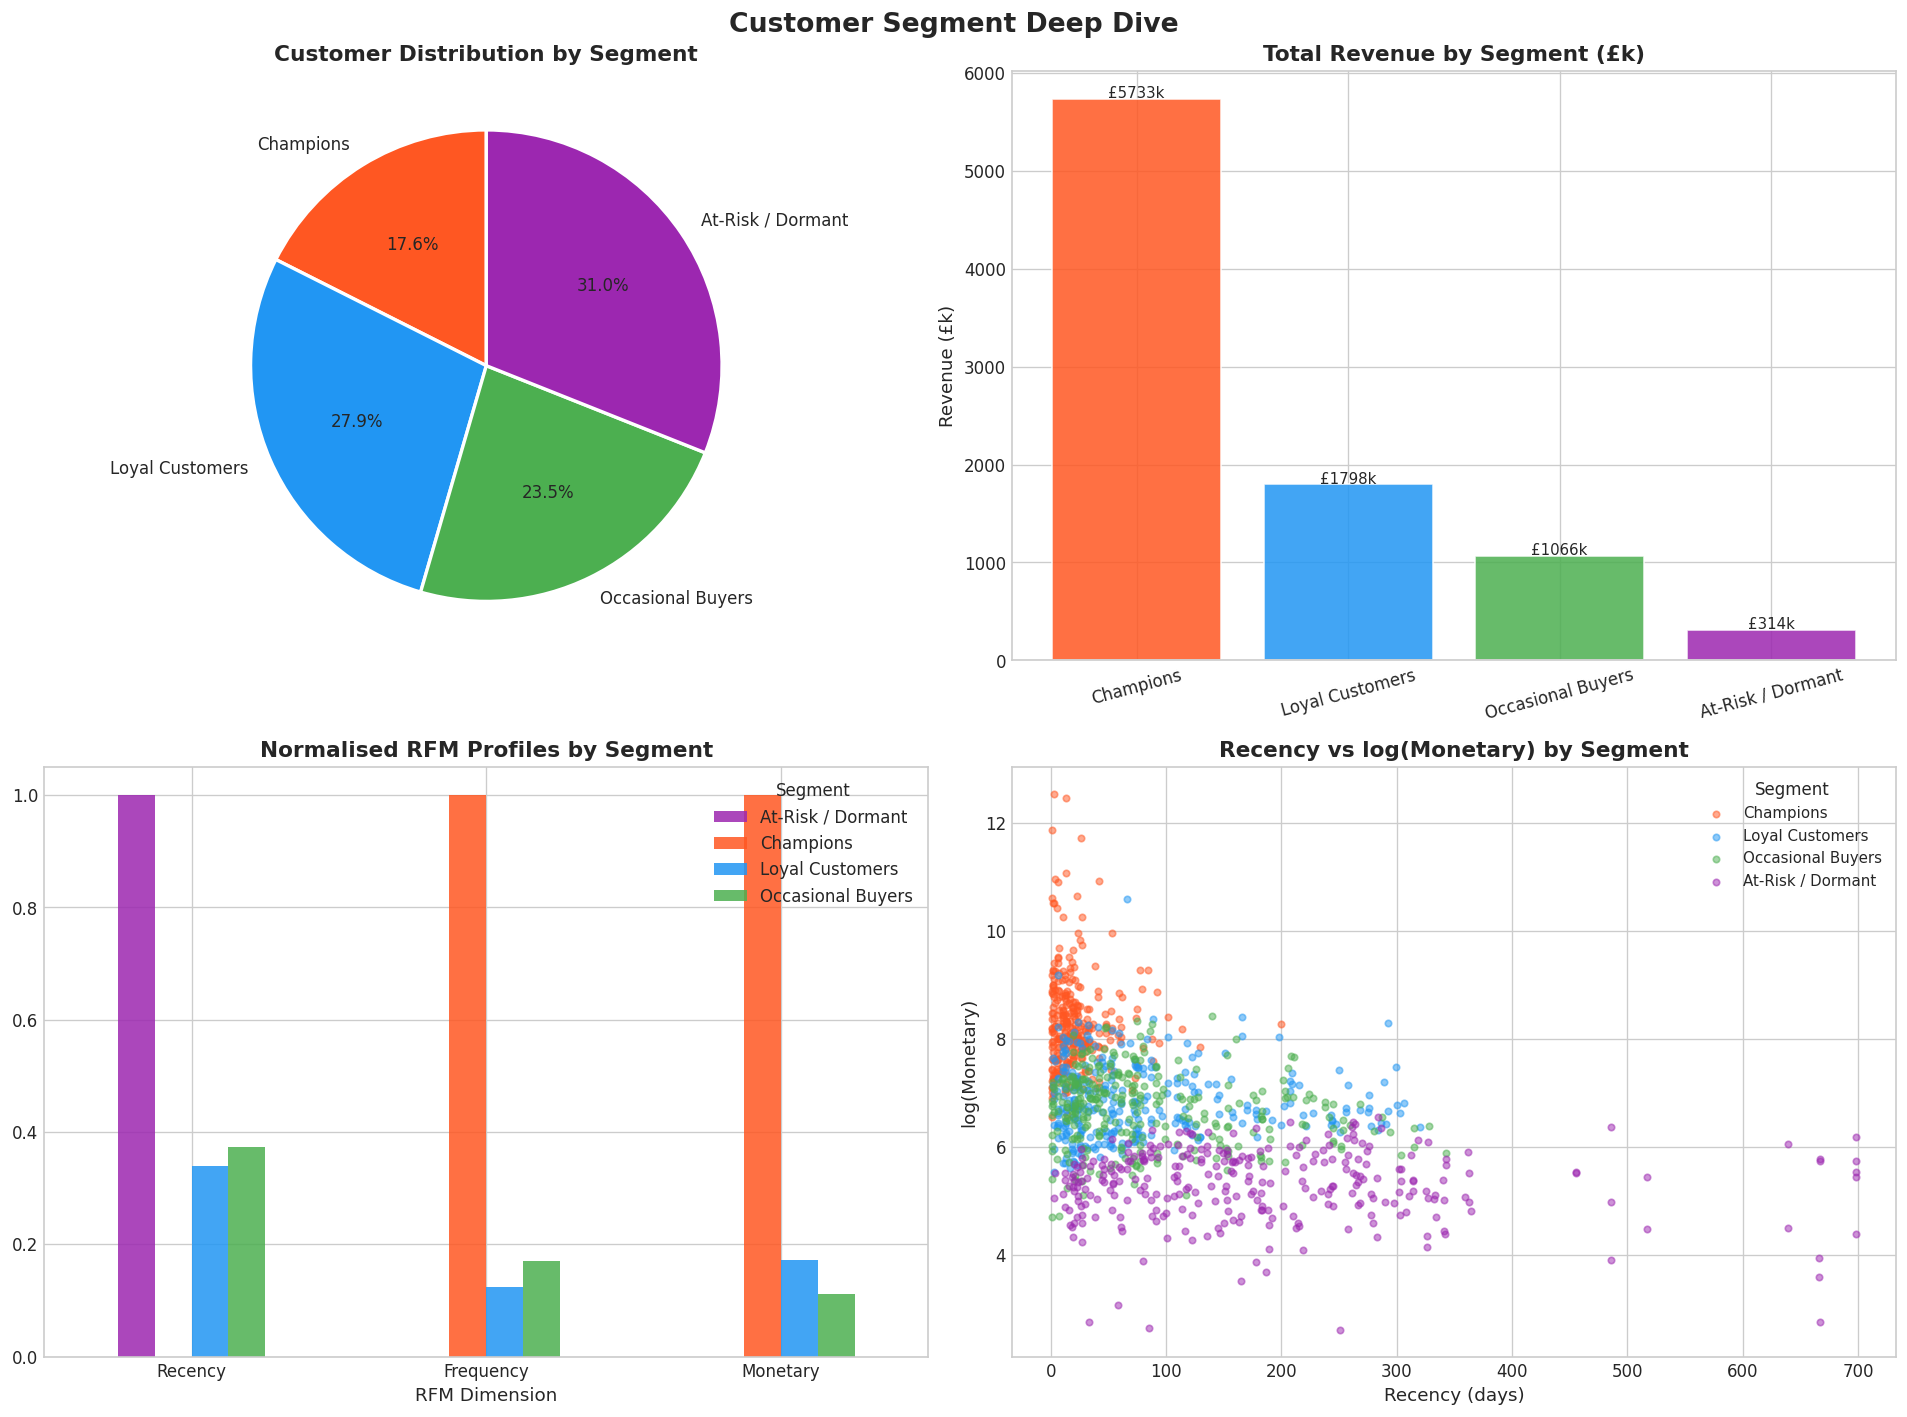

In [21]:
seg_order = ['Champions','Loyal Customers','Occasional Buyers','At-Risk / Dormant']
palette_s = [SEG_COLORS[s] for s in seg_order]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Customer Segment Deep Dive', fontsize=16, fontweight='bold')

counts_s = rfm['Segment'].value_counts()[seg_order]
axes[0,0].pie(counts_s, labels=seg_order, autopct='%1.1f%%',
              colors=palette_s, startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,0].set_title('Customer Distribution by Segment', fontweight='bold', fontsize=13)

rev_share = seg_stats['Total_Revenue'][seg_order]
bars = axes[0,1].bar(seg_order, rev_share/1000, color=palette_s, alpha=0.85, edgecolor='white')
axes[0,1].set_title('Total Revenue by Segment (£k)', fontweight='bold', fontsize=13)
axes[0,1].set_ylabel('Revenue (£k)'); axes[0,1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, rev_share/1000):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10, f'£{val:.0f}k', ha='center', fontsize=9)

seg_rfm = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()
seg_rfm_norm = (seg_rfm - seg_rfm.min()) / (seg_rfm.max() - seg_rfm.min())
seg_rfm_norm.T.plot(kind='bar', ax=axes[1,0],
                    color=[SEG_COLORS[s] for s in seg_rfm_norm.index], alpha=0.85)
axes[1,0].set_title('Normalised RFM Profiles by Segment', fontweight='bold', fontsize=13)
axes[1,0].set_xlabel('RFM Dimension'); axes[1,0].tick_params(axis='x', rotation=0)

for seg in seg_order:
    mask_s2 = rfm['Segment'] == seg
    sample2 = rfm[mask_s2].sample(min(300, mask_s2.sum()), random_state=42)
    axes[1,1].scatter(sample2['Recency'], np.log1p(sample2['Monetary']),
                      c=SEG_COLORS[seg], label=seg, alpha=0.5, s=15)
axes[1,1].set_title('Recency vs log(Monetary) by Segment', fontweight='bold', fontsize=13)
axes[1,1].set_xlabel('Recency (days)'); axes[1,1].set_ylabel('log(Monetary)')
axes[1,1].legend(title='Segment', fontsize=9)
plt.tight_layout()
plt.savefig('fig9_segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# =========================
# BUSINESS IMPACT (ROI)
# =========================

# Total revenue
total_revenue = rfm['Monetary'].sum()

# At-risk segment revenue
at_risk_revenue = seg_stats.loc['At-Risk / Dormant', 'Total_Revenue']

# Assume we retain 10% of at-risk customers
retention_rate = 0.10
recovered_revenue = at_risk_revenue * retention_rate

print("💰 BUSINESS IMPACT ESTIMATION")
print(f"Total Revenue: £{total_revenue:,.0f}")
print(f"At-Risk Revenue: £{at_risk_revenue:,.0f}")
print(f"Potential Recovery (10% retention): £{recovered_revenue:,.0f}")

💰 BUSINESS IMPACT ESTIMATION
Total Revenue: £8,911,408
At-Risk Revenue: £313,702
Potential Recovery (10% retention): £31,370


If 10% of at-risk customers are retained, the business can recover significant lost revenue.
This highlights the direct financial value of churn prediction models.

## 9. Churn Target Variable Definition

**Methodology (temporal train/test split):**

We split the timeline at the **75th percentile date**:
- **Observation window** (first 75%): Extract customer features here
- **Outcome window** (last 25%): If a customer does **NOT** reappear → **Churned (1)**

This mirrors real-world churn modelling: we use historical behaviour to forecast
whether a customer will remain active in the near future.

Observation window cutoff : 2011-10-10
Customers in model dataset: 3,854
Churn rate                : 55.89%
Retention rate            : 44.11%


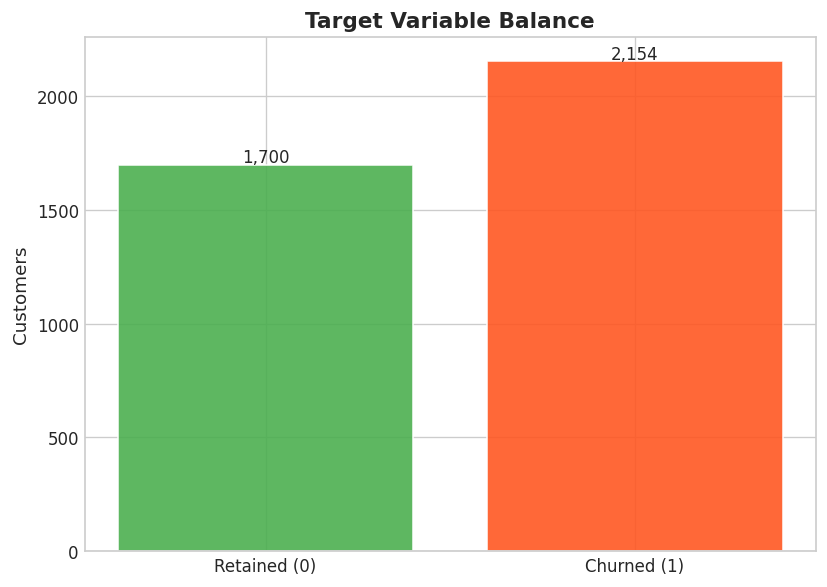

In [23]:
date_threshold = df['InvoiceDate'].quantile(0.75)
df_obs = df[df['InvoiceDate'] <= date_threshold]
df_out = df[df['InvoiceDate'] > date_threshold]
returned  = set(df_out['CustomerID'].unique())
SNAP_OBS  = date_threshold + pd.Timedelta(days=1)

model_df = df_obs.groupby('CustomerID').agg(
    Recency         = ('InvoiceDate', lambda x: (SNAP_OBS - x.max()).days),
    Frequency       = ('InvoiceNo',   'nunique'),
    Monetary        = ('Revenue',     'sum'),
    AvgOrderValue   = ('Revenue',     'mean'),
    NumProducts     = ('StockCode',   'nunique'),
    Tenuredays      = ('InvoiceDate', lambda x: (x.max()-x.min()).days),
    AvgTimeBetween  = ('InvoiceDate', lambda x:
                        (x.max()-x.min()).days/(x.nunique()-1) if x.nunique()>1 else 0),
    PurchasedWeekend= ('InvoiceDate', lambda x: int(x.dt.dayofweek.isin([5,6]).any())),
    RevenuePerVisit = ('Revenue',     'mean'),
).reset_index()
model_df['Churned'] = model_df['CustomerID'].apply(lambda c: 0 if c in returned else 1)

churn_rate = model_df['Churned'].mean()
print(f'Observation window cutoff : {date_threshold.date()}')
print(f'Customers in model dataset: {len(model_df):,}')
print(f'Churn rate                : {churn_rate:.2%}')
print(f'Retention rate            : {1-churn_rate:.2%}')

fig, ax = plt.subplots(figsize=(7, 5))
counts_ch = model_df['Churned'].value_counts()
ax.bar(['Retained (0)','Churned (1)'], [counts_ch[0], counts_ch[1]],
       color=[PALETTE[2], PALETTE[1]], alpha=0.9, edgecolor='white')
ax.set_title('Target Variable Balance', fontsize=13, fontweight='bold')
ax.set_ylabel('Customers')
for bar, cnt in zip(ax.patches, [counts_ch[0], counts_ch[1]]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10, f'{cnt:,}', ha='center')
plt.tight_layout(); plt.show()

## 10. Predictive Modelling & Evaluation

### Models
1. **Logistic Regression** — interpretable baseline; linear decision boundary
2. **Random Forest** — bagged ensemble of 200 trees; robust, handles non-linearity
3. **Gradient Boosting** — sequential boosting; captures complex interactions

### Evaluation Metrics
- **ROC-AUC**: Primary metric — measures ranking ability across all thresholds
- **F1 Score (Weighted)**: Accounts for class imbalance
- **5-Fold Stratified CV AUC**: Detects overfitting

In [24]:
FEAT_COLS = ['Recency','Frequency','Monetary','AvgOrderValue','NumProducts',
             'Tenuredays','AvgTimeBetween','PurchasedWeekend','RevenuePerVisit']

X_m = model_df[FEAT_COLS].fillna(0)
y_m = model_df['Churned']
X_tr, X_te, y_tr, y_te = train_test_split(X_m, y_m, test_size=0.2, random_state=42, stratify=y_m)

sc_m = StandardScaler()
X_tr_s = sc_m.fit_transform(X_tr)
X_te_s = sc_m.transform(X_te)

models_churn = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), True),
    'Random Forest'      : (RandomForestClassifier(n_estimators=200, max_depth=8,
                                                    random_state=42, n_jobs=-1), False),
    'Gradient Boosting'  : (GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                        learning_rate=0.05, random_state=42), False),
}
cv_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_churn = {}

for name, (model, use_scaled) in models_churn.items():
    Xtr_ = X_tr_s if use_scaled else X_tr.values
    Xte_ = X_te_s if use_scaled else X_te.values
    model.fit(Xtr_, y_tr)
    y_pred_ = model.predict(Xte_)
    y_proba_= model.predict_proba(Xte_)[:,1]
    cv_auc  = cross_val_score(model, Xtr_, y_tr, cv=cv_kf, scoring='roc_auc')
    results_churn[name] = {
        'model':model, 'y_pred':y_pred_, 'y_proba':y_proba_,
        'acc': accuracy_score(y_te, y_pred_),
        'f1' : f1_score(y_te, y_pred_, average='weighted'),
        'auc': roc_auc_score(y_te, y_proba_),
        'cv_auc': cv_auc.mean(), 'cv_std': cv_auc.std()
    }
    print(f'{name:25s}  ACC={results_churn[name]["acc"]:.4f}  '
          f'F1={results_churn[name]["f1"]:.4f}  '
          f'AUC={results_churn[name]["auc"]:.4f}  '
          f'CV={results_churn[name]["cv_auc"]:.4f}±{results_churn[name]["cv_std"]:.4f}')

best_name = max(results_churn, key=lambda k: results_churn[k]['auc'])
best = results_churn[best_name]
print(f'\n✅ Best model: {best_name} (AUC={best["auc"]:.4f})')
print()
print(classification_report(y_te, best['y_pred'], target_names=['Retained','Churned']))

Logistic Regression        ACC=0.6848  F1=0.6732  AUC=0.7255  CV=0.7233±0.0180
Random Forest              ACC=0.6952  F1=0.6914  AUC=0.7188  CV=0.7187±0.0153
Gradient Boosting          ACC=0.6783  F1=0.6746  AUC=0.7147  CV=0.7051±0.0154

✅ Best model: Logistic Regression (AUC=0.7255)

              precision    recall  f1-score   support

    Retained       0.71      0.49      0.58       340
     Churned       0.68      0.84      0.75       431

    accuracy                           0.68       771
   macro avg       0.69      0.66      0.66       771
weighted avg       0.69      0.68      0.67       771



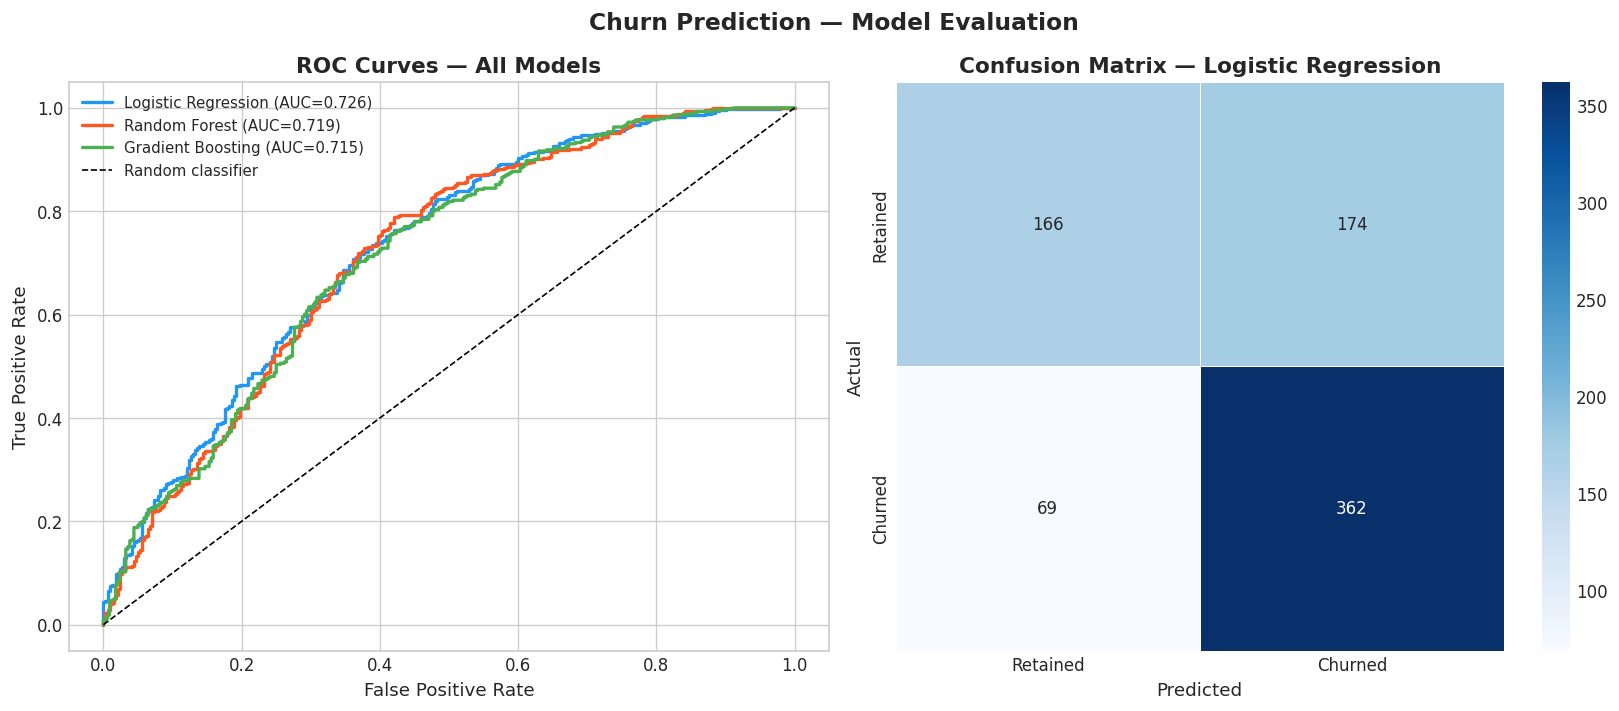

In [25]:
# ROC curves + confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Churn Prediction — Model Evaluation', fontsize=14, fontweight='bold')

for name, res in results_churn.items():
    fpr, tpr, _ = roc_curve(y_te, res['y_proba'])
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC={res["auc"]:.3f})')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random classifier')
axes[0].set_title('ROC Curves — All Models', fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)

cm = confusion_matrix(y_te, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Retained','Churned'],
            yticklabels=['Retained','Churned'], linewidths=0.5)
axes[1].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('fig10_churn_roc_cm.png', dpi=150, bbox_inches='tight')
plt.show()

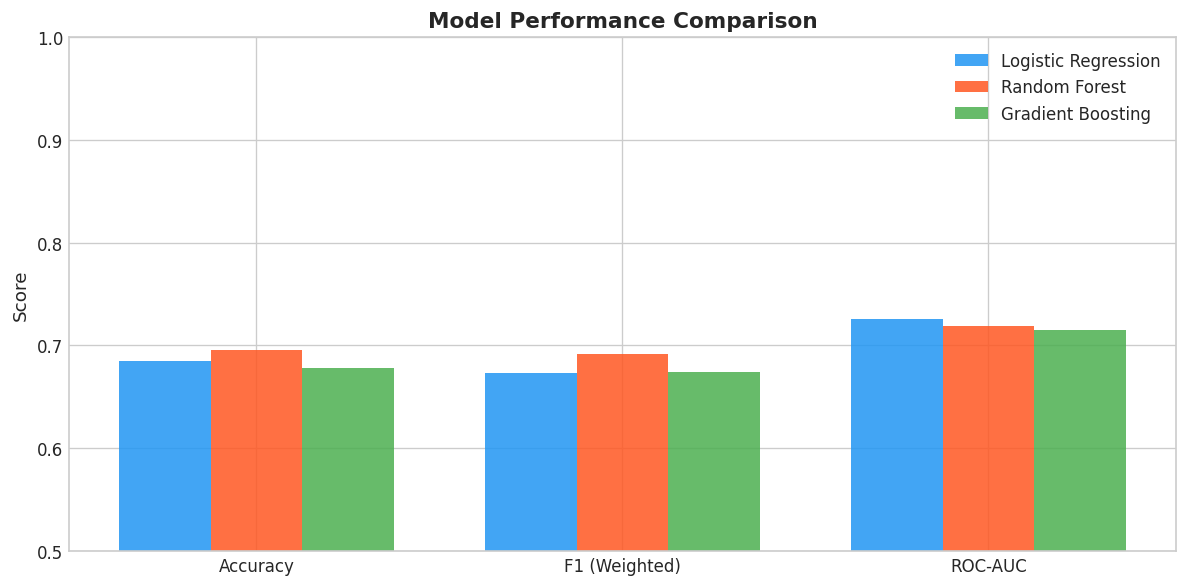

In [26]:
# Model comparison bar chart
metric_df = pd.DataFrame({
    name: {'Accuracy': res['acc'], 'F1 (Weighted)': res['f1'], 'ROC-AUC': res['auc']}
    for name, res in results_churn.items()
}).T
x = np.arange(3); w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
for i, (m, row) in enumerate(metric_df.iterrows()):
    ax.bar(x + i*w, row.values, w, label=m, color=PALETTE[i], alpha=0.85)
ax.set_xticks(x + w); ax.set_xticklabels(['Accuracy','F1 (Weighted)','ROC-AUC'])
ax.set_ylim(0.5, 1.0); ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Score'); ax.legend()
plt.tight_layout()
plt.savefig('fig11_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10b. Segment Classifier — Random Forest

Beyond churn prediction, we train a **Random Forest classifier** to predict
which K-Means segment a new customer belongs to, enabling **real-time segment
scoring** at point of purchase without needing to re-run clustering.

In [27]:
FEAT_SEG = ['log_Recency','log_Frequency','log_Monetary','log_AvgOrderValue']
le = LabelEncoder()
y_seg = le.fit_transform(rfm['Segment'])
X_seg = rfm[FEAT_SEG].values

X_str, X_ste, y_str, y_ste = train_test_split(
    X_seg, y_seg, test_size=0.2, random_state=42, stratify=y_seg)

rf_seg = RandomForestClassifier(n_estimators=200, random_state=42,
                                  n_jobs=-1, max_depth=12, min_samples_split=5)
rf_seg.fit(X_str, y_str)
y_seg_pred = rf_seg.predict(X_ste)

cv_seg = cross_val_score(rf_seg, X_seg, y_seg, cv=5, scoring='f1_weighted', n_jobs=-1)
print(f'5-Fold CV F1-Weighted: {cv_seg.mean():.4f} ± {cv_seg.std():.4f}')
print(f'Test Accuracy        : {accuracy_score(y_ste, y_seg_pred):.4f}')
print(f'Test F1 (weighted)   : {f1_score(y_ste, y_seg_pred, average="weighted"):.4f}')
print()
print(classification_report(y_ste, y_seg_pred, target_names=le.classes_))

5-Fold CV F1-Weighted: 0.7211 ± 0.0067
Test Accuracy        : 0.7431
Test F1 (weighted)   : 0.7341

                   precision    recall  f1-score   support

At-Risk / Dormant       0.86      0.95      0.90       269
        Champions       0.90      0.88      0.89       152
  Loyal Customers       0.66      0.72      0.69       243
Occasional Buyers       0.52      0.40      0.45       204

         accuracy                           0.74       868
        macro avg       0.73      0.74      0.73       868
     weighted avg       0.73      0.74      0.73       868



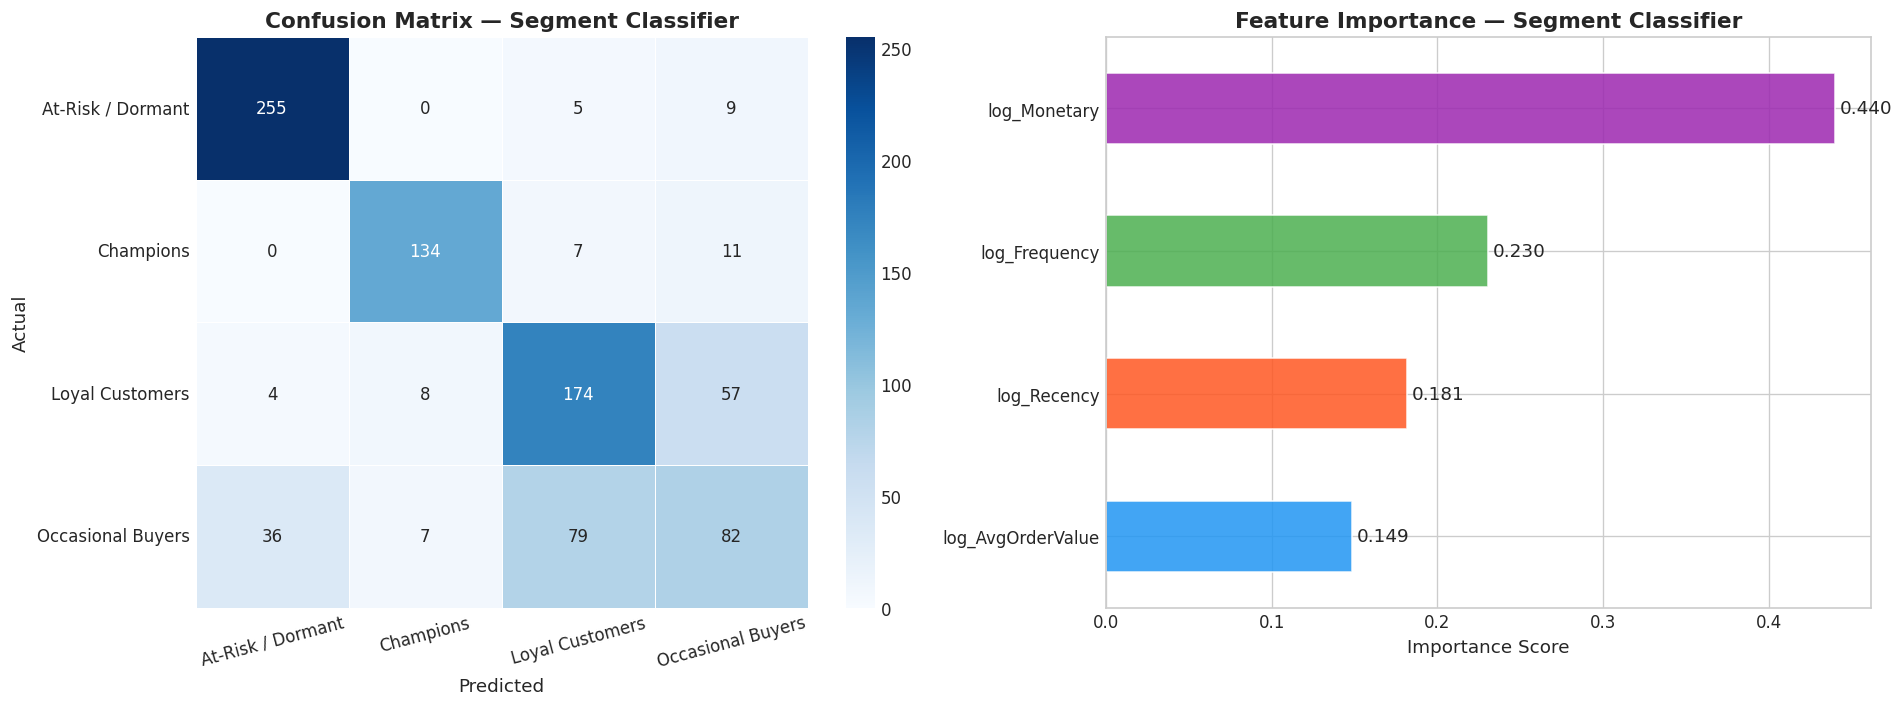

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm_seg = confusion_matrix(y_ste, y_seg_pred)
sns.heatmap(cm_seg, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.5)
axes[0].set_title('Confusion Matrix — Segment Classifier', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=15)

fi_seg = pd.Series(rf_seg.feature_importances_, index=FEAT_SEG).sort_values(ascending=True)
fi_seg.plot(kind='barh', ax=axes[1], color=PALETTE[:4], alpha=0.85, edgecolor='white')
axes[1].set_title('Feature Importance — Segment Classifier', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Importance Score')
for i, v in enumerate(fi_seg):
    axes[1].text(v+0.003, i, f'{v:.3f}', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('fig12_segment_classifier.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Feature Importance & Churn Drivers

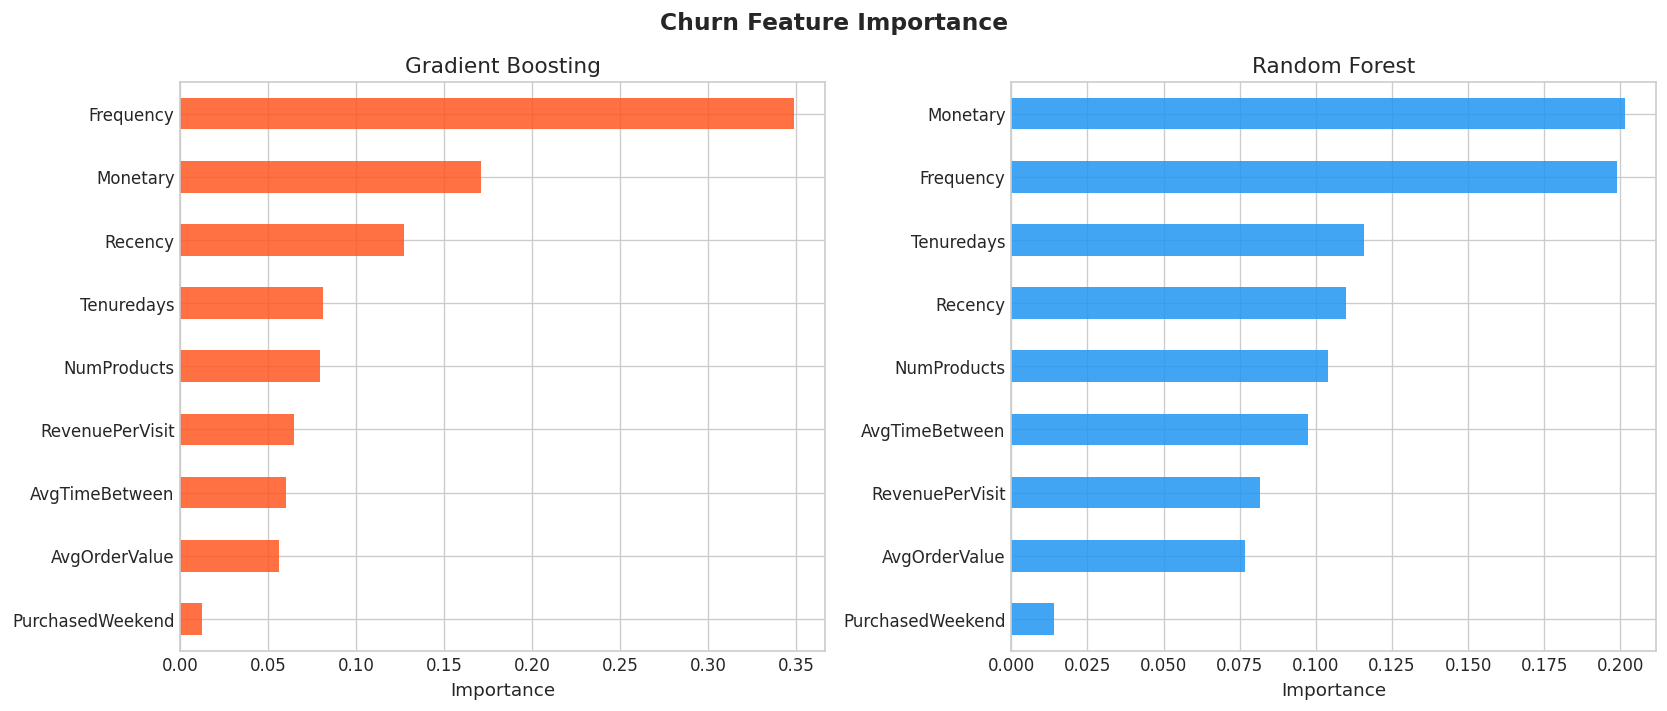

Top 5 Churn Drivers (Gradient Boosting):
Frequency      0.348995
Monetary       0.171037
Recency        0.127026
Tenuredays     0.081234
NumProducts    0.079275
dtype: float64


In [29]:
gb_model = results_churn['Gradient Boosting']['model']
rf_model = results_churn['Random Forest']['model']
fi_gb = pd.Series(gb_model.feature_importances_, index=FEAT_COLS).sort_values()
fi_rf = pd.Series(rf_model.feature_importances_, index=FEAT_COLS).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Churn Feature Importance', fontsize=14, fontweight='bold')
fi_gb.plot(kind='barh', ax=axes[0], color=PALETTE[1], alpha=0.85)
axes[0].set_title('Gradient Boosting'); axes[0].set_xlabel('Importance')
fi_rf.plot(kind='barh', ax=axes[1], color=PALETTE[0], alpha=0.85)
axes[1].set_title('Random Forest'); axes[1].set_xlabel('Importance')
plt.tight_layout()
plt.savefig('fig13_churn_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 Churn Drivers (Gradient Boosting):')
print(fi_gb.sort_values(ascending=False).head(5))

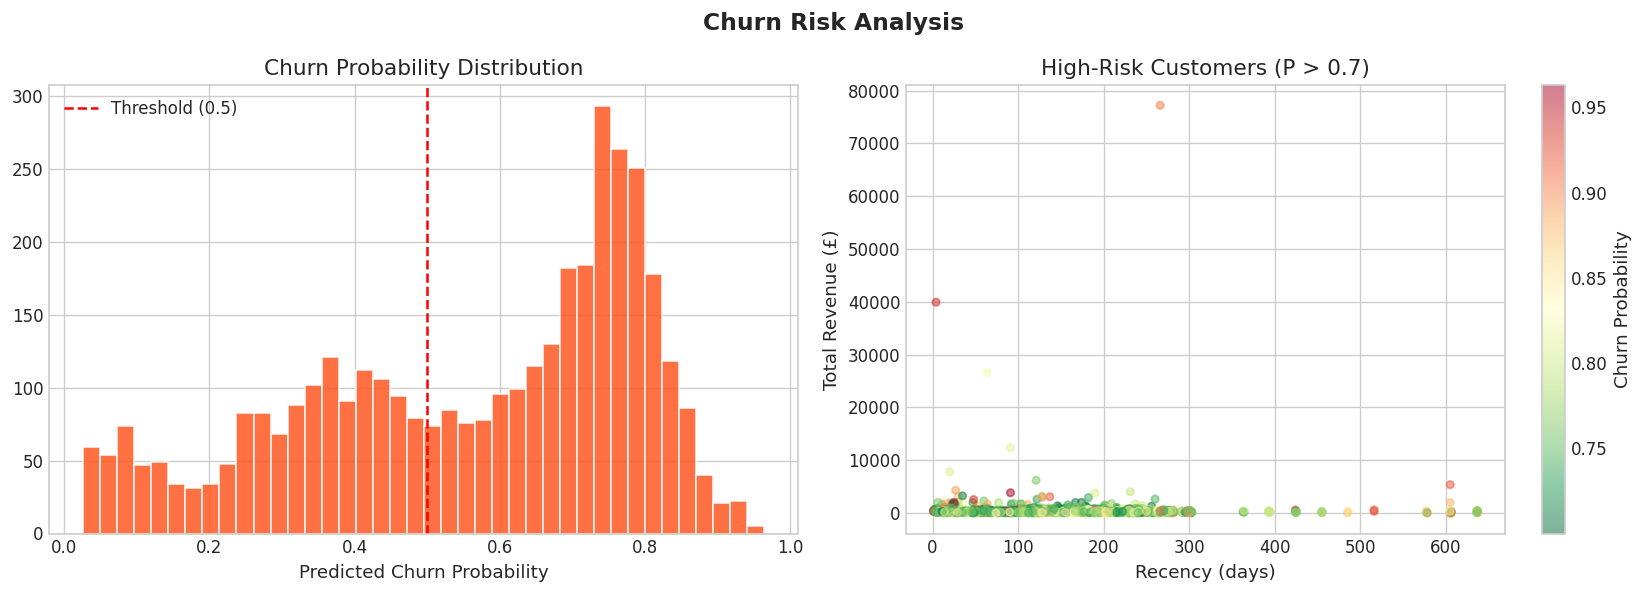

High-risk customers (P>0.7): 1,511
Revenue at risk            : £758,162


In [30]:
model_df['Churn_Prob'] = gb_model.predict_proba(model_df[FEAT_COLS].fillna(0).values)[:,1]
high_risk = model_df[model_df['Churn_Prob'] > 0.7]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn Risk Analysis', fontsize=14, fontweight='bold')
axes[0].hist(model_df['Churn_Prob'], bins=40, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[0].axvline(0.5, color='red', linestyle='--', label='Threshold (0.5)')
axes[0].set_title('Churn Probability Distribution')
axes[0].set_xlabel('Predicted Churn Probability'); axes[0].legend()
sc_plot = axes[1].scatter(high_risk['Recency'], high_risk['Monetary'],
                           c=high_risk['Churn_Prob'], cmap='RdYlGn_r', alpha=0.5, s=20)
plt.colorbar(sc_plot, ax=axes[1], label='Churn Probability')
axes[1].set_title('High-Risk Customers (P > 0.7)')
axes[1].set_xlabel('Recency (days)'); axes[1].set_ylabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('fig14_churn_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'High-risk customers (P>0.7): {len(high_risk):,}')
print(f'Revenue at risk            : £{high_risk["Monetary"].sum():,.0f}')

## 12. Inference Pipeline — Scoring New Customers

This function accepts raw customer behaviour metrics and returns:
- The predicted **customer segment**
- The predicted **churn probability**

In [31]:
def score_customer(recency, frequency, monetary):
    """
    Score a single new customer.
    recency  : int   – days since last purchase
    frequency: int   – number of unique orders
    monetary : float – total spend in £
    Returns: segment (str), segment_confidence (float), churn_probability (float)
    """
    import numpy as np
    avg_order = monetary / max(frequency, 1)
    seg_feats = np.array([[np.log1p(recency), np.log1p(frequency),
                            np.log1p(monetary), np.log1p(avg_order)]])
    seg_pred  = rf_seg.predict(seg_feats)[0]
    seg_proba = rf_seg.predict_proba(seg_feats)[0]
    segment   = le.inverse_transform([seg_pred])[0]
    seg_conf  = round(float(seg_proba[seg_pred]), 4)

    churn_feats = np.array([[recency, frequency, monetary, avg_order,
                              10, 0, 0, 0, avg_order]])
    churn_prob  = round(float(gb_model.predict_proba(churn_feats)[0,1]), 4)
    return segment, seg_conf, churn_prob

# Demo predictions
test_cases = [
    (5,  25, 12000, 'High-frequency recent buyer'),
    (90,  2,   200, 'Occasional buyer'),
    (350, 1,    50, 'Dormant customer'),
    (15, 10,  3000, 'Active loyal customer'),
    (200, 1,   400, 'At-risk customer'),
]
print(f'{"Customer Profile":<35} {"Segment":<22} {"Seg. Conf":>10} {"Churn P":>9}')
print('-'*80)
for r, f, m, label in test_cases:
    seg, conf, churn = score_customer(r, f, m)
    print(f'{label:<35} {seg:<22} {conf:>10.2%} {churn:>9.2%}')

Customer Profile                    Segment                 Seg. Conf   Churn P
--------------------------------------------------------------------------------
High-frequency recent buyer         Champions                 100.00%    79.06%
Occasional buyer                    At-Risk / Dormant          51.89%    70.26%
Dormant customer                    At-Risk / Dormant         100.00%    74.65%
Active loyal customer               Champions                 100.00%    88.80%
At-risk customer                    At-Risk / Dormant          77.70%    85.56%


## 13. Business Recommendations

### Segment Strategies

| Segment | Size | Revenue Share | Interpretation | Recommended Strategy |
|---|---|---|---|---|
| **Champions** | ~18% | ~64% | Most valuable, recent, frequent | VIP rewards, early access, brand ambassador program |
| **Loyal Customers** | ~28% | ~20% | Regular buyers, moderate spend | Loyalty programme, upsell premium products, referral incentives |
| **Occasional Buyers** | ~23% | ~12% | Growth opportunity | Bundle offers, personalised recommendations, first-repeat-purchase discount |
| **At-Risk / Dormant** | ~31% | ~4% | Disengaged, high churn risk | Win-back email sequence, limited-time discount (10–15%) |

### Key Insights from Feature Importance
1. **Frequency is the strongest churn driver** — customers who order less frequently are much more likely to churn. Focus on encouraging repeat purchases early in the customer lifecycle.
2. **Monetary value & Recency** also rank highly — high-spend customers who haven't bought recently are your most urgent win-back targets.
3. **Recency is the strongest segmentation signal** — it cleanly separates Champions from dormant customers.

### Timing & Geography
- Revenue **peaks in October–November** → launch campaigns in September to capture pre-holiday demand
- **Tuesday–Thursday** are peak order days → schedule email campaigns mid-week
- **Netherlands, EIRE, Germany** are the top international markets → invest in localised landing pages

### Churn Risk Action Plan
- **1,500+ customers** have churn probability > 70%, representing **£758K revenue at risk**
- Deploy automated win-back campaigns triggered when churn probability crosses 0.6
- Re-evaluate model quarterly as new transaction data arrives

## 14. Save Trained Models & Artefacts

In [32]:
import pickle, os
os.makedirs('models', exist_ok=True)

with open('models/kmeans_model.pkl','wb') as f:         pickle.dump(kmeans, f)
with open('models/scaler_cluster.pkl','wb') as f:       pickle.dump(scaler, f)
with open('models/rf_segment_classifier.pkl','wb') as f: pickle.dump(rf_seg, f)
with open('models/label_encoder.pkl','wb') as f:        pickle.dump(le, f)
with open('models/gb_churn_model.pkl','wb') as f:       pickle.dump(gb_model, f)
with open('models/scaler_churn.pkl','wb') as f:         pickle.dump(sc_m, f)

rfm.to_csv('models/rfm_segments.csv', index=False)
model_df.to_csv('models/churn_predictions.csv', index=False)

print('✅ Models saved:')
for fn in os.listdir('models'):
    size = os.path.getsize(f'models/{fn}')
    print(f'  models/{fn} ({size/1024:.1f} KB)')

✅ Models saved:
  models/churn_predictions.csv (336.1 KB)
  models/gb_churn_model.pkl (466.0 KB)
  models/gb_classifier.pkl (935.5 KB)
  models/kmeans_model.pkl (17.8 KB)
  models/label_encoder.pkl (0.3 KB)
  models/rfm_segments.csv (781.0 KB)
  models/rf_classifier.pkl (3024.9 KB)
  models/rf_segment_classifier.pkl (11315.2 KB)
  models/scaler.pkl (0.6 KB)
  models/scaler_churn.pkl (0.8 KB)
  models/scaler_cluster.pkl (0.8 KB)
  models/segment_map.pkl (0.1 KB)


In [33]:
print('=' * 62)
print('  PROJECT SUMMARY — E-Commerce Customer Segmentation')
print('=' * 62)
print(f'  Dataset          : {df.shape[0]:,} transactions, {rfm.shape[0]:,} unique customers')
print(f'  Date range       : {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')
print(f'  Countries        : {df["Country"].nunique()} | Products: {df["StockCode"].nunique():,}')
print(f'  Best Clustering  : K-Means (k=4) Silhouette={km_sil:.4f} DB={km_db:.4f}')
print(f'  Segment Classifier: RF F1={f1_score(y_ste, y_seg_pred, average="weighted"):.4f}')
print(f'  Churn Model      : {best_name} AUC={best["auc"]:.4f}')
print(f'  Churn Rate       : {churn_rate:.2%}')
print(f'  High-Risk Revenue: £{high_risk["Monetary"].sum():,.0f}')
print('=' * 62)
print()
print('  SEGMENT BREAKDOWN:')
for seg in seg_order:
    n   = (rfm['Segment'] == seg).sum()
    rev = rfm[rfm['Segment'] == seg]['Monetary'].sum()
    print(f'  {seg:<22} {n:>5,} customers  £{rev:>10,.0f}')

  PROJECT SUMMARY — E-Commerce Customer Segmentation
  Dataset          : 397,884 transactions, 4,338 unique customers
  Date range       : 2010-01-12 → 2011-12-10
  Countries        : 37 | Products: 3,665
  Best Clustering  : K-Means (k=4) Silhouette=0.2320 DB=1.4159
  Segment Classifier: RF F1=0.7341
  Churn Model      : Logistic Regression AUC=0.7255
  Churn Rate       : 55.89%
  High-Risk Revenue: £758,162

  SEGMENT BREAKDOWN:
  Champions                762 customers  £ 5,733,421
  Loyal Customers        1,212 customers  £ 1,798,132
  Occasional Buyers      1,018 customers  £ 1,066,152
  At-Risk / Dormant      1,346 customers  £   313,702


Model Demo

In [34]:
import joblib

churn_model = joblib.load('models/gb_churn_model.pkl')
scaler = joblib.load('models/scaler_churn.pkl')

segment_model = joblib.load('models/rf_segment_classifier.pkl')
encoder = joblib.load('models/label_encoder.pkl')

print("✅ All models loaded successfully")

✅ All models loaded successfully


In [35]:
sample = X_te.iloc[:5]   # take 5 rows
sample_scaled = scaler.transform(sample)

pred = churn_model.predict(sample_scaled)
print(pred)

[0 0 0 0 0]


In [36]:
proba = churn_model.predict_proba(sample_scaled)[:,1]
print(proba)

[0.07715379 0.07715379 0.07715379 0.08203272 0.07715379]


In [37]:
sample = X_te.sort_values('Recency', ascending=False).head(5)
sample_scaled = scaler.transform(sample)

print(churn_model.predict_proba(sample_scaled)[:,1])
print(churn_model.predict(sample_scaled))

[0.08663676 0.08663676 0.08663676 0.08663676 0.08663676]
[0 0 0 0 0]


In [38]:
sample_seg = X_seg[:10]

pred_seg = segment_model.predict(sample_seg)
decoded = encoder.inverse_transform(pred_seg)

print(decoded)

['Loyal Customers' 'Champions' 'Loyal Customers' 'Loyal Customers'
 'At-Risk / Dormant' 'Loyal Customers' 'At-Risk / Dormant'
 'Loyal Customers' 'Loyal Customers' 'Loyal Customers']


In [39]:
sample_seg = X_seg[np.random.choice(len(X_seg), 10, replace=False)]

pred_seg = segment_model.predict(sample_seg)
decoded = encoder.inverse_transform(pred_seg)

print(decoded)

['Loyal Customers' 'Occasional Buyers' 'Champions' 'Loyal Customers'
 'At-Risk / Dormant' 'At-Risk / Dormant' 'At-Risk / Dormant' 'Champions'
 'At-Risk / Dormant' 'Champions']


In [41]:
import joblib
model = joblib.load('models/gb_churn_model.pkl')
print("OK")

OK
